In [1]:
import numpy as np
import pandas as pd
import os
from getSimRes_old import getSimRes_old
import matplotlib.pyplot as plt

import sys
sys.path.append('C:/Users/fgarchitorena/Desktop/OpenFast/openfast_toolbox-main')
from openfast_toolbox.io import FASTOutputFile


ModuleNotFoundError: No module named 'openfast_toolbox'

In [2]:
plt.figure(figsize=(10, 5))
plt.rcParams.update({
    "text.usetex": False,
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 12,            # Tamaño general de la fuente
    "axes.titlesize": 16,       # Tamaño de la fuente para el título de los ejes
    "axes.labelsize": 14,       # Tamaño de la fuente para las etiquetas de los ejes
    "xtick.labelsize": 12,      # Tamaño de la fuente para las etiquetas de los ticks en el eje x
    "ytick.labelsize": 12,      # Tamaño de la fuente para las etiquetas de los ticks en el eje y
    "legend.fontsize": 12,      # Tamaño de la fuente para la leyenda
    "figure.titlesize": 16      # Tamaño de la fuente para el título de la figura
})

<Figure size 1000x500 with 0 Axes>

In [2]:
plt.figure(figsize=(12, 6))  # Aumentar el tamaño de la figura
plt.rcParams.update({
    "text.usetex": False,
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 20,            # Aumentar el tamaño general de la fuente
    "axes.titlesize": 26,       # Tamaño de la fuente para el título de los ejes
    "axes.labelsize": 24,       # Tamaño de la fuente para las etiquetas de los ejes
    "xtick.labelsize": 22,      # Tamaño de la fuente para las etiquetas de los ticks en el eje x
    "ytick.labelsize": 22,      # Tamaño de la fuente para las etiquetas de los ticks en el eje y
    "legend.fontsize": 22,      # Tamaño de la fuente para la leyenda
    "figure.titlesize": 26      # Tamaño de la fuente para el título de la figura
})

<Figure size 1200x600 with 0 Axes>

In [12]:
#----------------------DATOS DE ENTRADA------------------------------------------#

# Definición de los exponentes de Wöhler para diferentes variables
m_values = {
    'LSSGagMya_[kN-m]': 4, 
    'LSSGagMza_[kN-m]': 4, 
    'TwrBsMxt_[kN-m]': 4, 
    'TwrBsMyt_[kN-m]': 4
}

for i in range(1, 3):
    m_values[f'RootMxb{i}_[kN-m]'] = 10
    m_values[f'RootMyb{i}_[kN-m]'] = 10

# Lista de variables a analizar
variables = ['RootMxb1_[kN-m]','RootMyb1_[kN-m]', 'TwrBsMyt_[kN-m]', 'TwrBsMxt_[kN-m]']
varnames = ['EdgeWise','FlapWise', 'ForeAft', 'SideSide']
DLCs = ['1p1', '3p1', '4p1'] #'2p1'
DLCs_names = ['DLC 1.2','DLC 3.1','DLC 4.1']
TurbSim_DLCs = ['1p1','2p1'] 
dt = 0.00625                                                                # Paso temporal de las simulaciones.

# ENTRADAS DEL USUARIO
DLC_choice = '3p1'                                                          # DLC a analizar
DLC_name = '3.1'                                                            # Nombre del DLC a analizar
variation =''#'_ROSCO_SDTime' #'_TurbS'#'_ROSCO_SDTime'#                    # Variación: para el 4.1 sobre todo (para el resto pueden analizarse casos con turbSim)
root_name = 'IEA-3.4-130-RWT_'                                              # Nombre de la turbina de referencia utilizada
seeds = [13426, 13427, 13428, 13429, 13430, 13431]                          # Seeds for turbsim
DLC_folder = 'DLCs_post_pro' #DLCs_2                                        # Carpeta donde se encuentran los DLCs a analizar.
vel = [8.0,20.0]                                                            # Velocidades a analizar


# Parámetros constantes para la función getSimRes
Teq = 1
bins = 100  # Puede ser int o list
nbins = bins if isinstance(bins, int) else len(bins) - 1*(len(bins) > 1)
seeds_index = 0

# VENTANAS TEMPORALES A UTILIZAR 
#ventanas = [int(260/dt),int(560/dt), int(310/dt),int(610/dt), int(360/dt),int(660/dt)]
largo_ventana = '200s'
#ventanas = [int(320/dt),int(420/dt), int(340/dt),int(440/dt), int(360/dt),int(460/dt)]
#ventanas = [int(320/dt),int(420/dt), int(340/dt),int(440/dt), int(420/dt),int(520/dt)]
#ventanas = [int(320/dt),int(520/dt), int(340/dt),int(540/dt), int(460/dt),int(660/dt)]                               #VENTANAS DE "200" PARA EL DLC 3.1
####esta ventanas = [int(320/dt),int(520/dt), int(340/dt),int(540/dt), int(150/dt),int(350/dt)]                              # VENTANAS PARA EL DLC 4.1
ventanas = [int(320/dt),int(420/dt), int(320/dt),int(520/dt), int(320/dt),int(620/dt)]      #VENTANAS DE "100", "200", "300" y "400" para compara resultados de los DELs (DLC 3.1)
#ventanas = [int(1960/dt),int(2260/dt), int(2010/dt),int(2310/dt), int(2060/dt),int(2360/dt)]
#ventanas = [int(2020/dt),int(2120/dt), int(2040/dt),int(2140/dt), int(2060/dt),int(2160/dt)]                   
ventanas_legend = [f'Ventana 1: {ventanas[0]*dt-60}s a {ventanas[1]*dt-60}s',f'Ventana 2: {ventanas[2]*dt-60}s a {ventanas[3]*dt-60}s', f'Ventana 3: {ventanas[4]*dt-60}s a {ventanas[5]*dt-60}s']    #Nombres de las ventanas.

In [ ]:
#----------------------------SCRIPT PARA SACAR EN UN DATA FRAME LOS DELS DE CADA VARIABLE DE INTERES POR VENTANA TEMPORAL PARA CADA VELOCIDAD------------------------------#
# Columnas para el DataFrame (En caso de no querer sacar alguno de los datos, se pueden sacar de aqui las columnas)
columns = ["Simulation Name", "Leq"]+ \
    [f"S_{i}" for i in range(1, nbins + 1)] + \
    [f"N_{i}" for i in range(1, nbins + 1)] + \
    [f"bins_{i}" for i in range(1, nbins + 2)] + \
    [f"DELi_{i}" for i in range(1, nbins + 1)]    
    

# Diccionario para almacenar los resultados organizados por velocidad, ventana y variable
resultados = {v: {f'ventana_{i+1}': {var: [] for var in variables} for i in range(len(ventanas)//2)} for v in vel}

# Procesamiento de cada variable
for var in variables:
    m = m_values[var]
    
    # Simulaciones para diferentes velocidades de viento
    for v in vel:
        simName = f'{root_name}{DLC_choice}_{v}.outb'
        for i in range(0, len(ventanas), 2):
            
            #Defino ventanas temporales a utilizar
            start_index = ventanas[i]
            end_index = ventanas[i+1]
            
            #Obtengo los datos de post procesamiento para la variable de estudio, utilizando la función getSimRes.
            Leq, S, N, bins_ed, DELi, T  = getSimRes_old(simName, DLC_folder, var, m, Teq, bins, DLC_choice, start_index, end_index, variation, v, seeds_index=None, seeds=None)
            resultados[v][f'ventana_{i//2 + 1}'][var].append([simName, Leq]+ S.tolist() + N.tolist()+ bins_ed.tolist()+ DELi.tolist())  #Guardo datos en un diccionario

# Convertir resultados a DataFrames para análisis o gráficos: Data frame adentro de diccionario, adentro de dict, adentro de dict. (Esto no es necesario pero facilita a la hora de hacer los plots.)
#ver con type()
resultados_df = {
    v: {
        ventana: {
            var: pd.DataFrame(data, columns=columns) for var, data in vars_data.items()
            }
            for ventana, vars_data in ventanas_data.items()
        }
        for v, ventanas_data in resultados.items()
    }

# Ejemplo de uso de los DataFrames
for v, ventanas_data in resultados_df.items():
    for ventana, vars_data in ventanas_data.items():
        for var, df in vars_data.items():
            print(f"Resultados para {var} en {ventana} y velocidad {v}:")
            print(df.head())


In [ ]:
## RESULTADOS PARA VENTANA 3 ----------- Para comparar luego (Facilita a la hora de crear los plots separados)
ventanas_v3 = [int(420/dt),int(620/dt)]
ventanas_legend_v3 = [f'Ventana 3: {ventanas_v3[0]*dt-60}s a {ventanas_v3[1]*dt-60}s'] 
bins =100 
nbins = 100
# Columnas para el DataFrame
columns = ["Simulation Name", "Leq"]+ \
    [f"S_{i}" for i in range(1, nbins + 1)] + \
    [f"N_{i}" for i in range(1, nbins + 1)] + \
    [f"bins_{i}" for i in range(1, nbins + 2)] + \
    [f"DELi_{i}" for i in range(1, nbins + 1)]    
    

# Diccionario para almacenar los resultados organizados por velocidad, ventana y variable
resultados_v3 = {v: {f'ventana_{i+1}': {var: [] for var in variables} for i in range(len(ventanas_v3)//2)} for v in vel}

# Procesamiento de cada variable
for var in variables:
    m = m_values[var]
    
    # Simulaciones para diferentes velocidades de viento
    for v in vel:
        simName = f'{root_name}{DLC_choice}_{v}.outb'
        for i in range(0, len(ventanas_v3), 2):
            start_index = ventanas_v3[i]
            end_index = ventanas_v3[i+1]  
            Leq, S, N, bins_ed, DELi, T  = getSimRes_old(simName, DLC_folder, var, m, Teq, bins, DLC_choice, start_index, end_index, variation, v, seeds_index=None, seeds=None)
            resultados_v3[v][f'ventana_{i//2 + 1}'][var].append([simName, Leq]+ S.tolist() + N.tolist()+ bins_ed.tolist()+ DELi.tolist())

# Convertir resultados a DataFrames para análisis o gráficos: Data frame adentro de diccionario, adentro de dict, adentro de dict
#ver con type()
resultados_df_v3 = {
    v: {
        ventana: {
            var: pd.DataFrame(data, columns=columns) for var, data in vars_data.items()
            }
            for ventana, vars_data in ventanas_data.items()
        }
        for v, ventanas_data in resultados_v3.items()
    }

# Ejemplo de uso de los DataFrames
for v, ventanas_data in resultados_df_v3.items():
    for ventana, vars_data in ventanas_data.items():
        for var, df_v3 in vars_data.items():
            print(f"Resultados para {var} en {ventana} y velocidad {v}:")
            print(df_v3.head())

In [14]:
leq_all_values = []
num_ventanas = len(ventanas) // 2

# Para cada velocidad
vels = [8.0,20.0]
for v in vels:
    print(v)
    # Define un offset para las barras de cada velocidad
    for i, ventana in enumerate([f'ventana_{j+1}' for j in range(num_ventanas)]):
        leq_values = []
        for var in variables:
            leq_mean = np.mean(resultados_df[v][ventana][var]['Leq'])
            leq_values.append(leq_mean)
            leq_all_values.append(leq_mean)
max_value = max(leq_all_values)

8.0
20.0


20.0


NameError: name 'max_value' is not defined

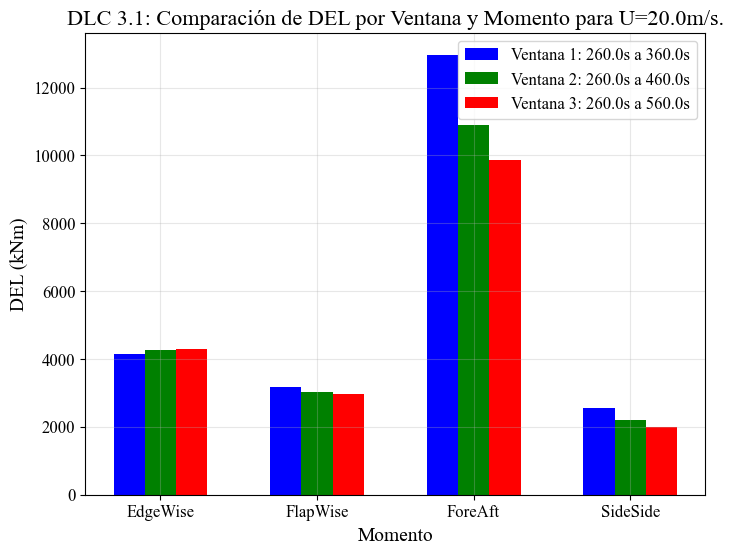

In [14]:
#-----------------------GRAFICOS DE BARRA DE LOS DELS POR MOMENTO PARA CADA VELOCIDAD PARA CADA VENTANA----------------------------------#
#ventanas = [int(320/dt),int(420/dt), int(340/dt),int(540/dt)]      #VENTANAS DE "200"
#ventanas_legend = [f'Ventana 1: {ventanas[0]*dt-60}s a {ventanas[1]*dt-60}s',f'Ventana 2: {ventanas[2]*dt-60}s a {ventanas[3]*dt-60}s',
#                   f'Ventana 3: {ventanas[4]*dt-60}s a {ventanas[5]*dt-60}s'],f'Ventana 4: {ventanas[6]*dt-60}s a {ventanas[7]*dt-60}s'] 
# Crea una figura y ejes
fig, ax = plt.subplots(figsize=(8, 6))

# Define el número de ventanas y variables
num_ventanas = len(ventanas) // 2
num_vars = len(variables)
#num_ventanas_v3 = len(ventanas_v3) // 2

# Define el ancho de las barras
bar_width = 0.2

# Define las posiciones de las barras en el eje x
index = np.arange(num_vars)

# Colores para diferenciar las ventanas
colors = ['b', 'g', 'r','m']
leq_all_values = []
# Para cada velocidad
vels = [20.0]
for v in vels:
    print(v)
    # Define un offset para las barras de cada velocidad
    for i, ventana in enumerate([f'ventana_{j+1}' for j in range(num_ventanas)]):
        leq_values = []
        for var in variables:
            # Obtiene el valor medio de Leq para la ventana y variable
            leq_mean = np.mean(resultados_df[v][ventana][var]['Leq'])
            #leq_mean = np.mean(resultados_df[v][ventana][var][0][1]) #Lo mismo, solo para mostrar que con el diccionario original también se puede obtener los datos
            leq_values.append(leq_mean)
            leq_all_values.append(leq_mean)
        # Crea las barras para cada ventana
        ax.bar(index + i * bar_width, leq_values, bar_width, label=f'{ventanas_legend[i]}', color=colors[i])
# for v in vels:
#     print(v)
#     # Define un offset para las barras de cada velocidad
#     for i, ventana in enumerate([f'ventana_{j+1}' for j in range(num_ventanas_v3)]):
#         leq_values = []
#         for var in variables:
#             # Obtiene el valor medio de Leq para la ventana y variable
#             leq_mean = np.mean(resultados_df_v3[v][ventana][var]['Leq'])
#             #leq_mean = np.mean(resultados_df[v][ventana][var][0][1])
#             leq_values.append(leq_mean)
#             print(leq_values)
#         # Plotting bars for each window
#         ax.bar(index + (2 * bar_width), leq_values, bar_width, label=f'{ventanas_legend_v3[i]}', color='r')
#         print(ventanas_legend_v3[i])        
    # Ajusta las etiquetas y el layout del gráfico
    ax.set_xlabel('Momento')
    ax.set_ylabel('DEL (kNm)')
    ax.set_title(f'DLC {DLC_name}: Comparación de DEL por Ventana y Momento para U={v}m/s.')
    ax.set_xticks(index + bar_width)
    ax.set_xticklabels(varnames)
    ax.legend()
    plt.grid(alpha=0.3)
    plt.ylim(0,max_value+1000)

    # Muestra el gráfico para cada velocidad
    plt.tight_layout()
    filename = f'Comp_DELs_dif_ancho_ventana_{DLC_choice}_{v}.png'
    #filename = f'DELs_{DLC_choice}_ventanas_conysin_evento_{v}.png'
    #directorio_save = f'C:/Users/fgarchitorena/Proyectos de investigacion/FSE_Incercia Sintética/Informe_UTE_DLCs/Imagenes_DLCs_2/post_pro/{DLC_choice}/N_vs_S/ventanas/{vels[0]}'# Cambia esto a la ruta deseada
    directorio_save = f'C:/Users/fgarchitorena/Proyectos de investigacion/FSE_Incercia Sintética/Informe_UTE_DLCs/Imagenes_DLCs_2/post_pro/{DLC_choice}/Comp_ventanas'# Cambia esto a la ruta deseada
    file_path = os.path.join(directorio_save, filename)
    #plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
    plt.show()


In [ ]:
#--------------------------------------ESTUDIO DEL EFECTO DE LA CANTIDAD DE BINS EN EL RESULTADO---------------------------------------------------#

#SACANDO RESULTADOS DE VENTANAS 1 Y 2 CON 100 Y 2000 BINS
ventanas_bins = [int(320/dt),int(520/dt), int(340/dt),int(540/dt)]      #VENTANAS DE "200"
ventanas_legend = [f'Ventana 1: {ventanas_bins[0]*dt-60}s a {ventanas_bins[1]*dt-60}s',f'Ventana 2: {ventanas_bins[2]*dt-60}s a {ventanas_bins[3]*dt-60}s'] 

for bins in np.array([100, 2000]):
    nbins = bins
    # Columnas para el DataFrame
    columns = ["Simulation Name", "Leq"]+ \
        [f"S_{i}" for i in range(1, nbins + 1)] + \
        [f"N_{i}" for i in range(1, nbins + 1)] + \
        [f"bins_{i}" for i in range(1, nbins + 2)] + \
        [f"DELi_{i}" for i in range(1, nbins + 1)]    
        

    # Diccionario para almacenar los resultados organizados por velocidad, ventana y variable
    if bins ==100:
        resultados_b100 = {v1: {f'ventana_{i+1}': {var: [] for var in variables} for i in range(len(ventanas_bins)//2)} for v1 in vel}
    else:
        resultados_b2000 = {v2: {f'ventana_{i+1}': {var: [] for var in variables} for i in range(len(ventanas_bins)//2)} for v2 in vel}
    # Procesamiento de cada variable
    for var in variables:
        m = m_values[var]
        
        # Simulaciones para diferentes velocidades de viento
        for v in vel:
            simName = f'{root_name}{DLC_choice}_{v}.outb'
            for i in range(0, len(ventanas_bins), 2):
                start_index = ventanas_bins[i]
                end_index = ventanas_bins[i+1]  
                Leq, S, N, bins_ed, DELi, T  = getSimRes_old(simName, DLC_folder, var, m, Teq, bins, DLC_choice, start_index, end_index, variation, v, seeds_index=None, seeds=None)
                if bins == 100:
                    resultados_b100[v][f'ventana_{i//2 + 1}'][var].append([simName, Leq]+ S.tolist() + N.tolist()+ bins_ed.tolist()+ DELi.tolist())
                else:
                    resultados_b2000[v][f'ventana_{i//2 + 1}'][var].append([simName, Leq]+ S.tolist() + N.tolist()+ bins_ed.tolist()+ DELi.tolist())
    # Convertir resultados a DataFrames para análisis o gráficos: Data frame adentro de diccionario, adentro de dict, adentro de dict
    #ver con type()
    if bins == 100:
        resultados_df_b100 = {
            v1: {
                ventana1: {
                    var: pd.DataFrame(data, columns=columns) for var, data in vars_data1.items()
                    }
                    for ventana1, vars_data1 in ventanas_data1.items()
                }
                for v1, ventanas_data1 in resultados_b100.items()
            }
        for v1, ventanas_data1 in resultados_df_b100.items():
            for ventana1, vars_data1 in ventanas_data1.items():
                for var, df1 in vars_data.items():
                    print(f"Resultados para {var} en {ventana} y velocidad {v1}:")
                    print(df1.head())        
    else:
        resultados_df_b2000 = {
            v2: {
                ventana2: {
                    var: pd.DataFrame(data, columns=columns) for var, data in vars_data2.items()
                    }
                    for ventana2, vars_data2 in ventanas_data2.items()
                }
                for v2, ventanas_data2 in resultados_b2000.items()
            }
        for v2, ventanas_data2 in resultados_df_b2000.items():
            for ventana2, vars_data2 in ventanas_data2.items():
                for var, df2 in vars_data.items():
                    print(f"Resultados para {var} en {ventana} y velocidad {v2}:")
                    print(df2.head())   


In [ ]:
# HISTOGRAMA PARA VER SI CAMBIA EL RESULTADO CAMBIANDO EL NUMERO DE BINS
ventanas_legend = [f'Ventana 1: {ventanas[0]*dt-60}s a {ventanas[1]*dt-60}s',f'Ventana 2: {ventanas[2]*dt-60}s a {ventanas[3]*dt-60}s'] 
# Crea una figura y ejes
fig, ax = plt.subplots(figsize=(8, 6))

# Define el número de ventanas y variables
num_ventanas = len(ventanas) // 2
num_vars = len(variables)
# Define el ancho de las barras
bar_width = 0.2

# Define las posiciones de las barras en el eje x
index = np.arange(num_vars)
print(index)
# Colores para diferenciar las ventanas
colors = ['b', 'g', 'r','m']

# Para cada velocidad
vels = [8.0]
for v in vels:
    print(v)
    # Define un offset para las barras de cada velocidad
    for i, ventana in enumerate([f'ventana_{j+1}' for j in range(num_ventanas)]):
        leq_values = []
        for var in variables:
            # Obtiene el valor medio de Leq para la ventana y variable
            leq_mean = np.mean(resultados_df_b2000[v][ventana][var]['Leq'])
            #leq_mean = np.mean(resultados_df[v][ventana][var][0][1])
            leq_values.append(leq_mean)
        
        # Plotting bars for each window
        ax.bar(index + i * (2 * bar_width), leq_values, bar_width, label=f'{ventanas_legend[i]}: bins=2000', color=colors[i])
for v in vels:
    print(v)
    # Define un offset para las barras de cada velocidad
    for i, ventana in enumerate([f'ventana_{j+1}' for j in range(num_ventanas)]):
        leq_values = []
        for var in variables:
            # Obtiene el valor medio de Leq para la ventana y variable
            leq_mean = np.mean(resultados_df_b100[v][ventana][var]['Leq'])
            #leq_mean = np.mean(resultados_df[v][ventana][var][0][1])
            leq_values.append(leq_mean)
           # print(leq_values)
        # Plotting bars for each window
        ax.bar(index + i * (2 * bar_width) + bar_width, leq_values, bar_width, label=f'{ventanas_legend[i]}: bins =100', color=colors[i+2])
    # Ajusta las etiquetas y el layout del gráfico
    ax.set_xlabel('Momento')
    ax.set_ylabel('DEL (kNm)')
    ax.set_title(f'DLC {DLC_name}: Comparación de DEL por Ventana y Momento para U={v}m/s. Comp. bins')
    ax.set_xticks(index + bar_width)
    ax.set_xticklabels(varnames)
    ax.legend()
    plt.grid(alpha=0.3)
    #plt.ylim(0,40000)
    #ax.legend(f'Ventana 1: {ventanas[0]*dt-60}s a {ventanas[1]*dt-60}s : bins = 2000',f'Ventana 1: {ventanas[0]*dt-60}s a {ventanas[1]*dt-60}s : bins = 100',
    #          f'Ventana 2: {ventanas[2]*dt-60}s a {ventanas[3]*dt-60}s : bins = 2000', f'Ventana 2: {ventanas[2]*dt-60}s a {ventanas[3]*dt-60}s : bins = 100')

    # Muestra el gráfico para cada velocidad
    plt.tight_layout()
    filename = f'DELs_ventana_{largo_ventana}_{DLC_choice}_{v}_comp_bins.png'
    directorio_save = f'C:/Users/fgarchitorena/Proyectos de investigacion/FSE_Incercia Sintética/Informe_UTE_DLCs/Imagenes_DLCs_2/post_pro/4p1/bins'# Cambia esto a la ruta deseada
    file_path = os.path.join(directorio_save, filename)
    plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
    plt.show()

In [ ]:
#COMPARACIÓN DE NUBES DE PUNTOS PARA DISTINTA CANTIDAD DE BINS#
# Define la variable y el contador

variables = ['RootMxb1_[kN-m]','RootMyb1_[kN-m]', 'TwrBsMyt_[kN-m]', 'TwrBsMxt_[kN-m]']
j = 0

for var in variables:
    # Itera por cada velocidad usando zip para iterar sobre ambos diccionarios
    for (v1, ventanas_data1), (v2, ventanas_data2) in zip(resultados_df_b100.items(), resultados_df_b2000.items()):
        plt.figure(figsize=(10, 6))  # Crear una sola figura por velocidad
        i = 0
        for (ventana1, vars_data1), (ventana2, vars_data2) in zip(ventanas_data1.items(), ventanas_data2.items()):
            if ventana1 == '':  # 'ventana_2' or 'ventana_3'  #Por si quiero excluir alguna ventana
                print('no juego')
            else:
                df1 = vars_data1[var]  # Data  frame para nbins = 100
                df2 = vars_data2[var]  # Data  frame para nbins = 2000

                # Verifica que el DataFrame tiene columnas con los nombres esperados
                S_columns_1 = [col for col in df1.columns if isinstance(col, str) and col.startswith('S_')]
                N_columns_1 = [col for col in df1.columns if isinstance(col, str) and col.startswith('N_')]
                bins_columns_1 = [col for col in df1.columns if isinstance(col, str) and col.startswith('bins_')]

                S_columns_2 = [col for col in df2.columns if isinstance(col, str) and col.startswith('S_')]
                N_columns_2 = [col for col in df2.columns if isinstance(col, str) and col.startswith('N_')]
                bins_columns_2 = [col for col in df2.columns if isinstance(col, str) and col.startswith('bins_')]

                # Extraer los valores de S_i y N_i
                S_values1 = df1[S_columns_1].values.flatten()
                N_values1 = df1[N_columns_1].values.flatten()
                bins_values1 = df1[bins_columns_1].values.flatten()

                S_values2 = df2[S_columns_2].values.flatten()
                N_values2 = df2[N_columns_2].values.flatten()
                bins_values2 = df2[bins_columns_2].values.flatten()

                # Añadir los datos de cada ventana al scatter plot
                plt.scatter(S_values1, N_values1, label=f'{ventanas_legend[i]}: bins = 100', marker='o', s=100)
                plt.scatter(S_values2, N_values2, label=f'{ventanas_legend[i]}: bins = 2000', marker='s',s = 100)

                i += 1

        # Configurar las etiquetas y el título del gráfico
        plt.xlabel('S_i (Rango de Carga)')
        plt.ylabel('N_i (Número de Ciclos)')
        plt.title(f'N vs S: {varnames[j]}, U = {v1}m/s, en todas las ventanas')
        plt.grid(True)
        plt.legend()  # Añadir la leyenda para identificar las ventanas

        # Guardar y mostrar el gráfico
        filename = f'N_vs_S_{DLC_choice}_{v1}_{varnames[j]}_comp_bins.png'
    # directorio_save = f'C:/Users/fgarchitorena/Desktop/Imagenes_DLCs_2/post_pro/bins'
        directorio_save = f'C:/Users/fgarchitorena/Proyectos de investigacion/FSE_Incercia Sintética/Informe_UTE_DLCs/Imagenes_DLCs_2/post_pro/{DLC_choice}/bins/{v1}'# Cambia esto a la ruta deseada
        file_path = os.path.join(directorio_save, filename)
        plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)

    j += 1


In [ ]:
resultados[8.0]['ventana_1']['RootMxb1_[kN-m]'][0]

In [ ]:
#NUBES DE PUNTOS N VS S PARA TODAS LAS VENTANAS Y LUEGO SOLO PARA LA VENTANA 3.
# Definir las variables que se van a analizar
if DLC_choice == '3p1':
    ventanas = [int(320/dt),int(520/dt), int(340/dt),int(540/dt), int(420/dt),int(620/dt)]      #VENTANAS DE "200"
else: 
    ventanas = [int(320/dt),int(520/dt), int(340/dt),int(540/dt), int(150/dt),int(350/dt)]
variables = ['RootMxb1_[kN-m]', 'RootMyb1_[kN-m]', 'TwrBsMyt_[kN-m]', 'TwrBsMxt_[kN-m]']
var_names = ['EdgeWise', 'FlapWise', 'ForeAft', 'SideSide']
ventanas_legend = [f'Ventana 1: {ventanas[0]*dt-60}s a {ventanas[1]*dt-60}s',f'Ventana 2: {ventanas[2]*dt-60}s a {ventanas[3]*dt-60}s']
ventanas_legend_v3 = [ f'Ventana 3: {ventanas[4]*dt-60}s a {ventanas[5]*dt-60}s']
markers=['o', 'X', 's' ]
colors = ['b', 'y', 'm']

# Generar gráficas para todas las cargas (variables) y velocidades, combinando datos de ventanas 1, 2 y 3
j = 0
for var in variables:
    for v, ventanas_data in resultados_df.items():
        plt.figure(figsize=(10, 6))  # Crear una sola figura por velocidad y variable
        i = 0
        for ventana, vars_data in ventanas_data.items():
            if ventana == 'ventana_3':
                continue  # No incluir ventana 3 en este bucle
            else:
                print(f'Procesando {ventana}, Velocidad: {v}, Variable: {var}') 
                df = vars_data[var]

                # Verifica que el DataFrame tiene las columnas esperadas
                S_columns = [col for col in df.columns if col.startswith('S_')]
                N_columns = [col for col in df.columns if col.startswith('N_')]

                S_values = df[S_columns].values.flatten()
                N_values = df[N_columns].values.flatten()

                plt.scatter(S_values, N_values, label=f'{ventanas_legend[i]}', marker=markers[i], color = colors[i], s=100)
                i += 1

        # Ahora, incluir la ventana 3 del resultados_df_v3
        for ventana, vars_data in resultados_df_v3[v].items():
            print(f'Procesando ventana 3, Velocidad: {v}, Variable: {var}')
            df_v3 = vars_data[var]

            S_columns_v3 = [col for col in df_v3.columns if col.startswith('S_')]
            N_columns_v3 = [col for col in df_v3.columns if col.startswith('N_')]

            S_values_v3 = df_v3[S_columns_v3].values.flatten()
            N_values_v3 = df_v3[N_columns_v3].values.flatten()

            plt.scatter(S_values_v3, N_values_v3, label=f'{ventanas_legend_v3[0]}', marker=markers[i], color='m', s=100)

        # Configurar las etiquetas y el título del gráfico
        plt.xlabel('S_i (Rango de Carga)')
        plt.ylabel('N_i (Número de Ciclos)')
        plt.title(f'N vs S para {var_names[j]} con U = {v} m/s.')
        plt.grid(True)
        plt.legend()

        # Guardar y mostrar el gráfico
        filename = f'N_vs_S_{var_names[j]}_velocidad_{v}_comp_ventanas.png'
        directorio_save = f'C:/Users/fgarchitorena/Proyectos de investigacion/FSE_Incercia Sintética/Informe_UTE_DLCs/Imagenes_DLCs_2/post_pro/{DLC_choice}/N_vs_S/ventanas/{v}'# Cambia esto a la ruta deseada
        file_path = os.path.join(directorio_save, filename)
        plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
        plt.show()
    j += 1

# Generar nubes de puntos únicamente para la ventana 3 (para todas las variables y velocidades)
j = 0
for var in variables:
    for v, ventanas_data_v3 in resultados_df_v3.items():
        plt.figure(figsize=(10, 6))  # Crear una figura por velocidad y variable
        i = 0
        for ventana, vars_data_v3 in ventanas_data_v3.items():
            print(f'Procesando ventana 3, Velocidad: {v}, Variable: {var}')
            df_v3 = vars_data_v3[var]

            S_columns_v3 = [col for col in df_v3.columns if col.startswith('S_')]
            N_columns_v3 = [col for col in df_v3.columns if col.startswith('N_')]

            S_values_v3 = df_v3[S_columns_v3].values.flatten()
            N_values_v3 = df_v3[N_columns_v3].values.flatten()

            plt.scatter(S_values_v3, N_values_v3, label=f'{ventanas_legend_v3[0]}', marker='s', color='m', s=100)

        # Configurar las etiquetas y el título del gráfico
        plt.xlabel('S_i (Rango de Carga)')
        plt.ylabel('N_i (Número de Ciclos)')
        plt.title(f'N vs S para {var_names[j]} en ventana 3 con U = {v} m/s')
        plt.grid(True)
        plt.legend()

        # Guardar y mostrar el gráfico
        filename = f'N_vs_S_{var_names[j]}_velocidad_{v}_ventana_3.png'
        #directorio_save = f'C:/Users/fgarchitorena/Desktop/Imagenes_DLCs_2/post_pro/N_vs_S/ventanas'
        directorio_save = f'C:/Users/fgarchitorena/Proyectos de investigacion/FSE_Incercia Sintética/Informe_UTE_DLCs/Imagenes_DLCs_2/post_pro/{DLC_choice}/N_vs_S/ventanas/{v}'# Cambia esto a la ruta deseada
        file_path = os.path.join(directorio_save, filename)
        plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
        plt.show()
    j+=1    


In [4]:
#NUBES DE PUNTOS DELi vs N PARA TODAS LAS VENTANAS Y LUEGO SOLO PARA LA VENTANA 3.
# Definir las variables que se van a analizar
markers=['o', 'X', 's' ]
colors = ['b', 'y', 'm']

# Generar gráficas para todas las cargas (variables) y velocidades, combinando datos de ventanas 1, 2 y 3
j = 0
for var in variables:
    for v, ventanas_data in resultados_df.items():
        plt.figure(num=f'Figura {j + 1}',figsize=(10, 6))  # Crear una sola figura por velocidad y variable
        i = 0
        for ventana, vars_data in ventanas_data.items():
            if ventana == 'ventana_3':
                continue  # No incluir ventana 3 en este bucle
            else:
                print(f'Procesando {ventana}, Velocidad: {v}, Variable: {var}') 
                df = vars_data[var]

                # Verifica que el DataFrame tiene las columnas esperadas
                DELi_columns = [col for col in df.columns if col.startswith('DELi_')]
                N_columns = [col for col in df.columns if col.startswith('N_')]
                N_columns = [col for col in df.columns if col.startswith('S_')]

                DELi_values = df[DELi_columns].values.flatten()
                N_values = df[N_columns].values.flatten()

#                plt.scatter(N_values, label=f'{ventanas_legend[i]}', marker=markers[i], color = colors[i], s=100)
                plt.scatter(N_values,DELi_values, label=f'{ventanas_legend[i]}', marker=markers[i], color = colors[i], s=100)

                i += 1

        # Ahora, incluir la ventana 3 del resultados_df_v3
        for ventana, vars_data in resultados_df_v3[v].items():
            print(f'Procesando ventana 3, Velocidad: {v}, Variable: {var}')
            df_v3 = vars_data[var]

            DELi_columns_v3 = [col for col in df_v3.columns if col.startswith('DELi_')]
            N_columns_v3 = [col for col in df_v3.columns if col.startswith('N_')]
            N_columns_v3 = [col for col in df_v3.columns if col.startswith('S_')]

            DELi_values_v3 = df_v3[DELi_columns_v3].values.flatten()
            N_values_v3 = df_v3[N_columns_v3].values.flatten()

            #plt.scatter(DELi_values_v3, N_values_v3, label=f'{ventanas_legend_v3[0]}', marker=markers[i], color='m', s=100)
            plt.scatter(N_values_v3,DELi_values_v3, label=f'{ventanas_legend_v3[0]}', marker=markers[i], color='m', s=100)

        # Configurar las etiquetas y el título del gráfico
        plt.xlabel('DELi (DEL por bin)')
        plt.ylabel('S_i (Número de Ciclos)')
        plt.title(f'N vs DELi para {var_names[j]} con U = {v} m/s.')
        plt.grid(True)
        plt.legend()

        # Guardar y mostrar el gráfico
        filename = f'N_vs_DELi_{var_names[j]}_velocidad_{v}_comp_ventanas.png'
        directorio_save = f'C:/Users/fgarchitorena/Proyectos de investigacion/FSE_Incercia Sintética/Informe_UTE_DLCs/Imagenes_DLCs_2/post_pro/{DLC_choice}/N_vs_DELi/{v}'# Cambia esto a la ruta deseada
        file_path = os.path.join(directorio_save, filename)
        #plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
        plt.show()
    j += 1

# Generar nubes de puntos únicamente para la ventana 3 (para todas las variables y velocidades)
j = 0
for var in variables:
    for v, ventanas_data_v3 in resultados_df_v3.items():
        plt.figure(figsize=(10, 6))  # Crear una figura por velocidad y variable
        i = 0
        for ventana, vars_data_v3 in ventanas_data_v3.items():
            print(f'Procesando ventana 3, Velocidad: {v}, Variable: {var}')
            df_v3 = vars_data_v3[var]

            DELi_columns_v3 = [col for col in df_v3.columns if col.startswith('DELi_')]
            N_columns_v3 = [col for col in df_v3.columns if col.startswith('N_')]
            N_columns_v3 = [col for col in df_v3.columns if col.startswith('S_')]

            DELi_values_v3 = df_v3[DELi_columns_v3].values.flatten()
            N_values_v3 = df_v3[N_columns_v3].values.flatten()

            #plt.scatter(DELi_values_v3, N_values_v3, label=f'{ventanas_legend_v3[0]}', marker='s', color='m', s=100)
            plt.scatter(N_values_v3, DELi_values_v3, label=f'{ventanas_legend_v3[0]}', marker='s', color='m', s=100)

        # Configurar las etiquetas y el título del gráfico
        plt.xlabel('DELi (DEL por bin)')
        plt.ylabel('S_i (Número de Ciclos)')
        plt.title(f'N vs DELi para {var_names[j]} en ventana 3 con U = {v} m/s')
        plt.grid(True)
        plt.legend()

        # Guardar y mostrar el gráfico
        filename = f'N_vs_DELi_{var_names[j]}_velocidad_{v}_ventana_3.png'
        #directorio_save = f'C:/Users/fgarchitorena/Desktop/Imagenes_DLCs_2/post_pro/N_vs_S/ventanas'
        directorio_save = f'C:/Users/fgarchitorena/Proyectos de investigacion/FSE_Incercia Sintética/Informe_UTE_DLCs/Imagenes_DLCs_2/post_pro/{DLC_choice}/N_vs_DELi/{v}'# Cambia esto a la ruta deseada
        file_path = os.path.join(directorio_save, filename)
        #plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
        plt.show()
    j+=1    


NameError: name 'variables' is not defined

In [16]:
from getSimRes_old import getSimRes_old

# DEL para cada caso, ambas velocidades, todos los momentos.
# Columnas para el DataFrame
columns = ["Simulation Name", "Leq"]#+ \
   # [f"S_{i}" for i in range(1, nbins + 1)] + \
    #[f"N_{i}" for i in range(1, nbins + 1)]

DLCs = ['1p1','4p1','3p1']
DLC_folder = 'DLCs_post_pro'
# Diccionario para almacenar los resultados organizados por velocidad, ventana y variable
#resultados = {v: {f'DLC_{i+1}': {var: [] for var in variables} for i in range(len(DLCs)//2)} for v in vel}
resultados_comp = {DLC_choice: {v: {var: [] for var in variables} for v in vel} for DLC_choice in DLCs}
vel = [8.0, 20.0]
vel = [12.0]
# Procesamiento de cada variable
for DLC_choice in DLCs:
    for v in vel:
        for var in variables: 
            m = m_values[var]
            if DLC_choice in TurbSim_DLCs:
                variation = ''
                simName = f'{root_name}{DLC_choice}_{v}_sd1.outb'
                #ind = seeds.index(sd)
                Leq, S, N, bins, DELi,T = getSimRes_old(simName, DLC_folder, var, m, 1, nbins, DLC_choice, int(60/dt), int(660/dt), variation, v, 'sd1', seeds)
                print(Leq)
                resultados_comp[DLC_choice][v][var].append([simName, Leq])#+ S.tolist() + N.tolist())
            elif DLC_choice == '4p1':
                variation = '_ROSCO_SDTime'#'_TurbS'#
                simName = f'{root_name}{DLC_choice}_{v}.outb'  
                Leq, S, N, bins, DELi,T = getSimRes_old(simName, DLC_folder, var, m, 0.5, nbins, DLC_choice, int(260/dt), int(560/dt), variation, v, seeds_index=None, seeds=None)
                resultados_comp[DLC_choice][v][var].append([simName, Leq])#+ S.tolist() + N.tolist())
                variation = ''
            else:
                DLC_folder = 'DLCs_post_pro'
                variation = ''#'_TurbS' #DLC_folder = 'DLCs_2' int(1960/dt), int(2260/dt)
                simName = f'{root_name}{DLC_choice}_{v}.outb'  
                Leq, S, N, bins, DELi,T = getSimRes_old(simName, DLC_folder, var, m, 0.5, nbins, DLC_choice,int(260/dt), int(560/dt), variation, v, seeds_index=None, seeds=None)
                resultados_comp[DLC_choice][v][var].append([simName, Leq])#+ S.tolist() + N.tolist())
# Convertir resultados a DataFrames para análisis o gráficos: Data frame adentro de diccionario, adentro de dict, adentro de dict
#ver con type()
resultados_df_comp = {
    DLC_choice: {
        v: {
            var: pd.DataFrame(data, columns=columns) for var, data in vars_data.items()
            }
            for v, vars_data in v_data.items()
        }
        for DLC_choice, v_data in resultados_comp.items()
    }

# Ejemplo de uso de los DataFrames
for DLC_choice, v_data in resultados_df_comp.items():
    for v, vars_data in v_data.items():
        for var, df in vars_data.items():
            print(f"Resultados para {var} en DLC {DLC_choice} y velocidad {v}:")
            print(df.head())

C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_post_pro/DLC_1/1p1/12.0/sd1/IEA-3.4-130-RWT_1p1_12.0_sd1.outb
4741.343343730567
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_post_pro/DLC_1/1p1/12.0/sd1/IEA-3.4-130-RWT_1p1_12.0_sd1.outb
5296.331876418116
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_post_pro/DLC_1/1p1/12.0/sd1/IEA-3.4-130-RWT_1p1_12.0_sd1.outb
20365.415994605533
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_post_pro/DLC_1/1p1/12.0/sd1/IEA-3.4-130-RWT_1p1_12.0_sd1.outb
11240.101837018961
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_post_pro/DLC_4/4p1_ROSCO_SDTime/12.0/IEA-3.4-130-RWT_4p1_12.0.outb
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_post_pro/DLC_4/4p1_ROSCO_SDTime/12.0/IEA-3.4-130-RWT_4p1_12.0.outb
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_post_pro/DLC_4/4p1_ROSCO_SDTime/12.0/IEA-3.4-130-RWT_4p1_12.0.outb
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_post_pro/DLC_4/4p1_ROSCO_SDTime/12.0/IEA-3.4-130-RWT_4p1_12.0.outb
C:/Users/fgarchitorena/Desktop/OpenFast/DLCs_post_

In [62]:
#resultados_df_comp['1p1'][8.0]['RootMxb1_[kN-m]']['S_1']
#resultados_df_comp['1p1'][8.0]['RootMxb1_[kN-m]']
#type(resultados_df_comp['1p1'][8.0]['RootMxb1_[kN-m]'])
type(vars_data[var])

pandas.core.frame.DataFrame

In [20]:
np.mean(resultados_df_comp['1p1'][8.0]['TwrBsMyt_[kN-m]']['Leq'])
#resultados_df_comp[DLC_choice][v][var]['Leq']
#print(m,nbins)
print(TurbSim_DLCs)

['1p1', '2p1']


8.0
0
1
2
3


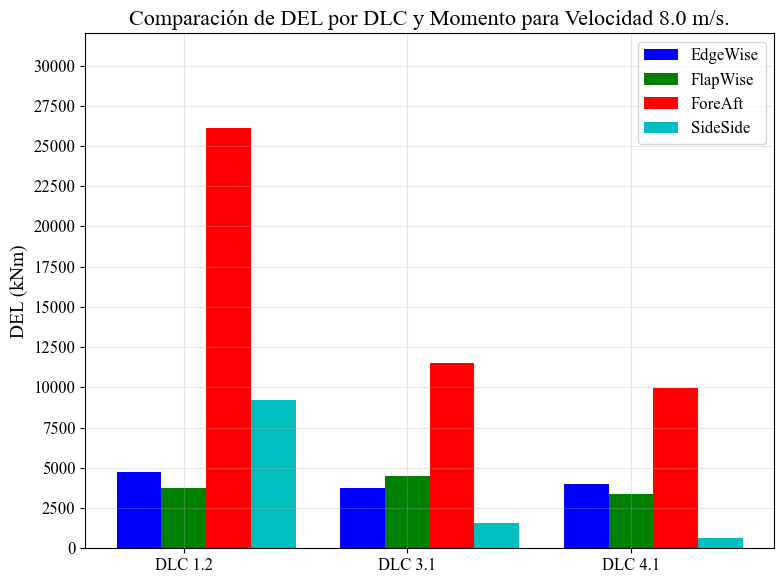

In [7]:
#Gráfico de barras:

# Crea una figura y ejes
fig, ax = plt.subplots(figsize=(8, 6))

# Define el número de ventanas y variables
num_DLCs = len(DLCs)
num_vars = len(variables)

# Define el ancho de las barras
bar_width = 0.2

# Define las posiciones de las barras en el eje x
index = np.arange(num_DLCs)

# Colores para diferenciar las ventanas
colors = ['b', 'g', 'r','c']

# Para cada velocidad
vel = [8.0]
for v in vel:
    print(v)
    i=0
    # Define un offset para las barras de cada velocidad
    for var in variables:
        leq_values = []
        for DLC_choice in DLCs:
            # Obtiene el valor medio de Leq para la ventana y variable
            leq_mean = np.mean(resultados_df_comp[DLC_choice][v][var]['Leq'])
            #leq_mean = np.mean(resultados_comp[v][ventana][var][0][1])
            leq_values.append(leq_mean)
        
        # Plotting bars for each window
        print(i)
        ax.bar(index + i * bar_width, leq_values, bar_width, label=f'{varnames[i]}', color=colors[i])
        i =i+1
    # Ajusta las etiquetas y el layout del gráfico
    #ax.set_xlabel('DLC')
    ax.set_ylabel('DEL (kNm)')
    ax.set_title(f'Comparación de DEL por DLC y Momento para Velocidad {v} m/s.') #Casos con turbulencia')
    ax.set_xticks(index + bar_width)
    plt.locator_params(axis='y', nbins=15)
    ax.set_xticklabels(DLCs_names)
    ax.legend()
    plt.grid(alpha=0.3)
    plt.ylim(0,32000)

    # Muestra el gráfico para cada velocidad
    plt.tight_layout()
    filename = f'DELs_comp_{v}.png'#_TurbS.png'
    directorio_save = f'C:/Users/fgarchitorena/Desktop/Imagenes_DLCs_2/post_pro/'# Cambia esto a la ruta deseada
    file_path = os.path.join(directorio_save, filename)
    #plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
    plt.show()